In [3]:
from gstools import SRF, Gaussian       # GeoStatTools is a library that provides geostatistical tools for
                                        # random field generation and variogram estimation. Spatial Random fields are generated
                                        # by a class called SRF. We need also "Gaussian" because we want to generate
                                        # a Gaussian random field
import matplotlib.pyplot as plt
import numpy as np
import torch
import math

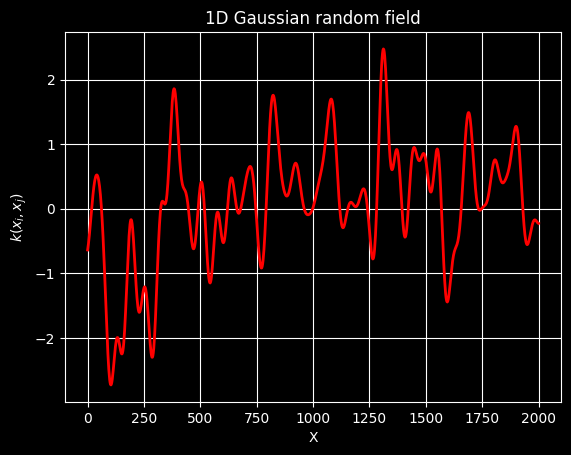

In [34]:
# Field's features
N = 2**10 # size
X = torch.linspace(0, 2000, N) # dimensions of X: N points between -10 and 1000

# Define the 2D generator model with variance = 1 and length-scale = 50
gauss_model = Gaussian(dim=1, var=1, len_scale=30) # which is the best choice for the variance and the length-scale??
srf = SRF(gauss_model) # field initialization

# Generate two fields
field = srf.structured(X)           # Generate the field on a structured mesh. It needs the axes and the seed (optional).
                                    # It is a numpy array of dimension (X, Y)
# field2 = srf.structured([X, Z])

# # Visualization: case of two fields
# fig, ax = plt.subplots(1, 2, sharex=False, sharey=True, figsize=(8, 4))
# ax[0].imshow(field, aspect='auto')
# ax[0].set_title('First Field (1024 x 1024)')
# ax[1].imshow(field2,  aspect='auto')
# ax[1].set_title('Second Field (1024 x 8)')

# Visualization: case of one single field
fig = plt.figure(1)
plt.plot(X, field, color='red', linewidth=2)
plt.title('1D Gaussian random field')
plt.xlabel('X')
plt.ylabel('$k(x_i, x_j)$')
plt.grid(True)
#plt.show()

# Convert the field (Numpy arrays) to PyTorch tensors
field_tensor = torch.from_numpy(field).float()


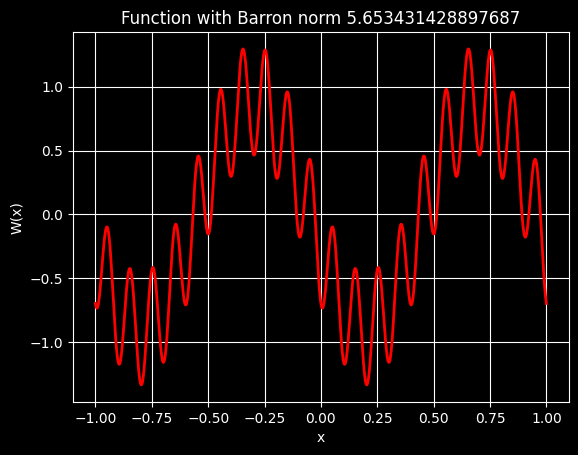

In [36]:

"""---------------------------------
 Goal: Create a function hard to approximate
       with two frequency components
------------------------------------"""
# In order to have the same random generation each time
np.random.seed(0)

# Parameters
s=1                 # power for the weight
omega1 = 1          # low frequency
omega2 = 10         # high frequency
phi1 = np.random.uniform(0, 2*math.pi)      # phase shift
phi2 = np.random.uniform(0, 2*math.pi)      # phase shift
w1 = (1+np.abs(omega1)**2)**(s/2)           # weight function
w2 = (1+np.abs(omega2)**2)**(s/2)           # weight function
F1 = 0.9                                    # amplitude
F2 = np.sqrt(1-F1**2)                       # amplitude -> Normalization : F1^2 + F2^2 = 1 (Parseval's theorem)

# Evaluate the Barron norm (p = 1)
barron_norm = F1*w1 + F2*w2

# Spatial domain
x = torch.linspace(-1,1,N)

# Create the function we want to approximate
W = F1 * torch.sin(2*math.pi*omega1*x + phi1) + F2 * torch.sin(2*math.pi*omega2*x + phi2)

# Visualization
fig = plt.figure(2)
plt.plot(x, W, color='red', linewidth=2)
plt.title(f'Function with Barron norm {barron_norm}')
plt.xlabel('x')
plt.ylabel('W(x)')
plt.grid(True)
plt.show()